In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping

## Carregamento dos dados

In [10]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

## Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.04),
    tf.keras.layers.RandomTranslation(0.3, 0.3),
], name = "data_augmentation")

## Visualização dos dados

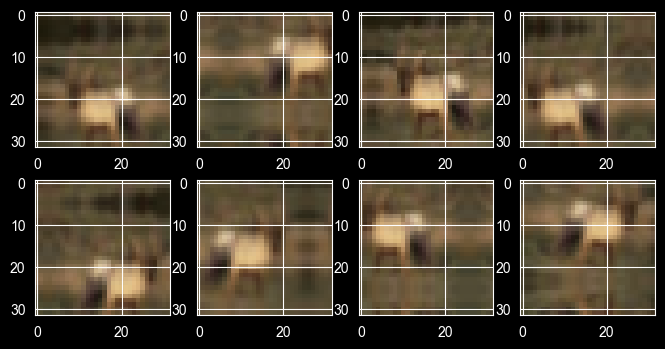

In [12]:
plt.figure(figsize=(8,4))

sample = x_train[3:4]

for i in range(8):
    aug = data_augmentation(sample, training=True)

    plt.subplot(2, 4, i + 1)
    plt.imshow(aug[0].numpy())

# Construção do Modelo

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 data_augmentation (Sequent  (None, 32, 32, 3)         0         
 ial)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                      

## Compilação + Early Stopping

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

## Treinamento

In [15]:
history = model.fit(x_train, y_train,
                    validation_split=0.1,
                    epochs=30,
                    batch_size=128,
                    callbacks=[early_stop],
                    verbose=2
                    )

Epoch 1/30
352/352 - 36s - loss: 1.8568 - accuracy: 0.3119 - val_loss: 1.6886 - val_accuracy: 0.3902 - 36s/epoch - 102ms/step
Epoch 2/30
352/352 - 32s - loss: 1.6018 - accuracy: 0.4140 - val_loss: 1.4330 - val_accuracy: 0.4750 - 32s/epoch - 92ms/step
Epoch 3/30
352/352 - 29s - loss: 1.5010 - accuracy: 0.4537 - val_loss: 1.4018 - val_accuracy: 0.4856 - 29s/epoch - 83ms/step
Epoch 4/30
352/352 - 30s - loss: 1.4109 - accuracy: 0.4897 - val_loss: 1.3971 - val_accuracy: 0.5070 - 30s/epoch - 85ms/step
Epoch 5/30
352/352 - 28s - loss: 1.3506 - accuracy: 0.5129 - val_loss: 1.2667 - val_accuracy: 0.5488 - 28s/epoch - 81ms/step
Epoch 6/30
352/352 - 31s - loss: 1.2915 - accuracy: 0.5359 - val_loss: 1.1616 - val_accuracy: 0.5786 - 31s/epoch - 89ms/step
Epoch 7/30
352/352 - 28s - loss: 1.2469 - accuracy: 0.5562 - val_loss: 1.0524 - val_accuracy: 0.6236 - 28s/epoch - 80ms/step
Epoch 8/30
352/352 - 31s - loss: 1.2075 - accuracy: 0.5687 - val_loss: 1.0528 - val_accuracy: 0.6238 - 31s/epoch - 87ms/step